In [1]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [ ]:
from langchain.chat_models import init_chat_model
model=init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000289A53D8B80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000289A53D9390>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
# from langchain.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

In [15]:
help(SummarizationMiddleware)

Help on class SummarizationMiddleware in module langchain.agents.middleware.summarization:

class SummarizationMiddleware(langchain.agents.middleware.types.AgentMiddleware)
 |  SummarizationMiddleware(model: str | langchain_core.language_models.chat_models.BaseChatModel, *, trigger: tuple[typing.Literal['fraction'], float] | tuple[typing.Literal['tokens'], int] | tuple[typing.Literal['messages'], int] | list[tuple[typing.Literal['fraction'], float] | tuple[typing.Literal['tokens'], int] | tuple[typing.Literal['messages'], int]] | None = None, keep: tuple[typing.Literal['fraction'], float] | tuple[typing.Literal['tokens'], int] | tuple[typing.Literal['messages'], int] = ('messages', 20), token_counter: collections.abc.Callable = <function count_tokens_approximately at 0x00000289A45C2DD0>, summary_prompt: str = '<role>\nContext Extraction Assistant\n</role>\n\n<primary_objective>\nYour sole objective in this task is to extract the highest quality/most relevant context from the conversati

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

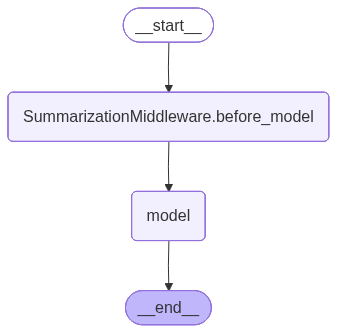

In [18]:
agent=create_agent(
    model="groq:qwen/qwen3-32b", 
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
        model="groq:qwen/qwen3-32b",
        trigger=("messages", 10),
        keep=("messages", 4)
        )
    ]  
)
agent

In [19]:
config={"thread_id": "test"}

In [ ]:
questions=[
    "What is the capital of France?",
    "What is the capital of Germany?",
    "What is the capital of Japan?",
    "What is the capital of Italy?",   
    "What is the capital of Spain?",
    "What is the capital of Portugal?",
    "What is the capital of the Netherlands?"
]

In [22]:
for q in questions:
    response= agent.invoke({"messages":HumanMessage(content=q)}, config=config)
    print(f"Messages: {response}")
    print(f"Message: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='a47a839a-4192-4bb3-93e5-a7ca95356bd2'), AIMessage(content="<think>\nOkay, so I need to figure out the capital of France. Hmm, I remember from school that France is a country in Europe. Let me think... I know Paris is a big city there, and I've heard it mentioned in the context of being a capital. But wait, isn't there also Lyon? Or maybe Marseille? No, I think Lyon is another major city, maybe the second largest? Marseille is on the Mediterranean coast, right? So maybe Paris is the capital. But how can I be sure?\n\nLet me recall some historical facts. France was part of the Roman Empire, and they called it Gallia. The capital might have changed over time. I think during the Middle Ages, Paris was an important city. Louis XIV, the Sun King, ruled from Versailles, but that's a palace outside Paris. So even though he had his court at Versailles, the capital city 

### Human in the Loop
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [76]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

def read_email_tool(email_id:str) ->str:
    """Mock function to read email content based on email_id."""
    return "Email content"

def send_email_tool(to:str, subject:str, body:str):
    """Mock function to send an email."""
    return (f"Email sent to {to} with subject {subject} and body {body}")


agent=create_agent(
    model="groq:qwen/qwen3-32b", 
    tools=[send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

### Accept


In [77]:
config={"thread_id": "email_thread"}
response= agent.invoke({"messages":HumanMessage(content="Send an email to Vyomika with subject 'Course Marking' and body 'Let's meet tomorrow.'")}, config=config)

In [78]:
response

{'messages': [HumanMessage(content="Send an email to Vyomika with subject 'Course Marking' and body 'Let's meet tomorrow.'", additional_kwargs={}, response_metadata={}, id='d06c889c-b6bc-4929-91f9-897c4fbdf7f6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants to send an email to Vyomika with the subject 'Course Marking' and the body 'Let's meet tomorrow.' I need to use the send_email_tool provided. First, I'll check the function parameters. The required fields are to, subject, and body. All three are provided here: to is Vyomika, subject is 'Course Marking', and the body is 'Let's meet tomorrow.' I just need to structure the JSON correctly. Make sure the email address for Vyomika is correctly formatted. No other parameters are needed. So the tool_call should include these three arguments properly.\n", 'tool_calls': [{'id': '1afz2fcdx', 'function': {'arguments': '{"body":"Let\'s meet tomorrow.","subject":"Course Marking","to":"vyomika@ex

In [79]:
from langgraph.types import Command
if "__interrupt__" in response:
    print("Interrupted, waiting for human decision...")

    response=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

Interrupted, waiting for human decision...


In [80]:
print(f"Result: {response['messages'][-1].content}")


Result: The email with the subject "Course Marking" and the body "Let's meet tomorrow." has been successfully sent to Vyomika at vyomika@example.com. Let me know if you need anything else!


### To reject

In [81]:
# For rejecting the tool execution (rejecting the email sending): 
config={"thread_id": "reject_email_thread"}

In [82]:
response= agent.invoke({"messages":HumanMessage(content="Send an email to Vyomika with subject 'Course Marking' and body 'Let's meet tomorrow.'")}, config=config)

In [83]:
if "__interrupt__" in response:
    print("Interrupted, waiting for human decision...")

    response=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )

Interrupted, waiting for human decision...


In [84]:
print(f"Result: {response['messages'][-1].content}")

Result: The email to Vyomika was not sent as the tool call was rejected. Would you like me to send the email now or assist with something else?


In [85]:
response

{'messages': [HumanMessage(content="Send an email to Vyomika with subject 'Course Marking' and body 'Let's meet tomorrow.'", additional_kwargs={}, response_metadata={}, id='36730037-b2da-43d1-847d-0d82ef59a0ae'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to Vyomika. Let me check the tools available. There's a send_email_tool. The parameters required are to, subject, and body. The user provided all three: to is Vyomika, subject is 'Course Marking', and body is 'Let's meet tomorrow.' I need to structure the JSON with these arguments. Make sure the keys are correct and the values are strings. No missing parameters. Should be straightforward.\n", 'tool_calls': [{'id': 'qehw717eb', 'function': {'arguments': '{"body":"Let\'s meet tomorrow.","subject":"Course Marking","to":"Vyomika"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 193, 'total_tokens':

#### To edit

In [90]:
# For editing the tool execution (editing the email content before sending):
config={"thread_id": "email_edit_thread"}
response=agent.invoke({"messages":HumanMessage(content="Send an email to wrongemail@example.com with subject 'Course Marking' and body 'Let's meet tomorrow.'")}, config=config)

In [91]:
if "__interrupt__" in response:
    print("Interrupted, waiting for human decision...")

    response=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {
                        "type": "edit",
                        "edited_action":{
                            "name":"send_email_tool", # Tool name
                            "args":{                # Arguments for the tool execution
                                "to":"Vyomika",
                                "subject":"Deep Learning",
                                "body":"This was edited by human in the loop middleware.",
                            }
                        },
                     }
                ]
            }
        ),
        config=config
    )

Interrupted, waiting for human decision...


In [92]:
response

{'messages': [HumanMessage(content="Send an email to wrongemail@example.com with subject 'Course Marking' and body 'Let's meet tomorrow.'", additional_kwargs={}, response_metadata={}, id='5c8dc685-4e38-45d4-893d-a920933b37fa'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants me to send an email to wrongemail@example.com with the subject 'Course Marking' and the body 'Let's meet tomorrow.' Let me check the tools provided. There's a function called send_email_tool. The parameters required are to, subject, and body. All three are required. The user provided all three: the to address is wrongemail@example.com, subject is 'Course Marking', and the body is 'Let's meet tomorrow.' So I need to call the send_email_tool with these arguments. I should make sure the JSON is correctly formatted with the parameters. Let me double-check the email address and the message to avoid any typos. Everything looks good. The tool call should include the name of the functi

In [93]:
print(f"Result: {response['messages'][-1].content}")

Result: It seems that the email was modified by a human-in-the-loop middleware before being sent. The original request was to send an email to **wrongemail@example.com** with the subject **"Course Marking"** and body **"Let's meet tomorrow."** However, the middleware altered the recipient to **Vyomika**, changed the subject to **"Deep Learning"**, and modified the body to **"This was edited by human in the loop middleware."**

Would you like me to:
1. Send the original email as requested (without middleware interference)?
2. Confirm the modified email was sent correctly?
3. Take another action?
